# Ulcer Prediction Model

### Import Libraries

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error,root_mean_squared_error
from xgboost import XGBRegressor
import pickle

### Load Data 

In [6]:
df = pd.read_csv(r"/content/ulcer_prediction.csv")
df.head(5)

,Patient_ID,Age,Gender,Height_cm,Weight_kg,Smoking,Alcohol_Use,NSAID_Use,Stress_Level,Family_History,H_Pylori_Status,Abdominal_Pain,Nausea,Vomiting,Bloating,Loss_of_Appetite,Heartburn,Melena,Hematemesis,Ulcer_Risk_Score
0,P0001,57,Male,176.0,93.8,No,No,Yes,6,No,0,No,No,No,No,No,No,No,Yes,0.3553
1,P0002,47,Female,147.0,60.5,No,Yes,Yes,4,No,0,Yes,No,Yes,No,No,No,No,No,0.3752
2,P0003,59,Male,174.9,85.6,Yes,No,Yes,2,No,1,Yes,No,No,No,Yes,No,No,No,0.5385
3,P0004,72,Male,155.2,57.5,No,Yes,No,2,No,0,No,Yes,No,Yes,No,No,No,No,0.2493
4,P0005,46,Male,177.0,88.5,Yes,No,No,3,No,0,No,No,No,No,Yes,No,No,No,0.1439


###  Explore Data

In [7]:
print(df.shape)
print(df.columns)

(2991, 20)
Index(['Patient_ID', 'Age', 'Gender', 'Height_cm', 'Weight_kg', 'Smoking',
       'Alcohol_Use', 'NSAID_Use', 'Stress_Level', 'Family_History',
       'H_Pylori_Status', 'Abdominal_Pain', 'Nausea', 'Vomiting', 'Bloating',
       'Loss_of_Appetite', 'Heartburn', 'Melena', 'Hematemesis',
       'Ulcer_Risk_Score'],
      dtype='object')


### Summary statistics and null value count

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2991 entries, 0 to 2990
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Patient_ID        2991 non-null   object 
 1   Age               2991 non-null   int64  
 2   Gender            2991 non-null   object 
 3   Height_cm         2991 non-null   float64
 4   Weight_kg         2991 non-null   float64
 5   Smoking           2991 non-null   object 
 6   Alcohol_Use       2991 non-null   object 
 7   NSAID_Use         2991 non-null   object 
 8   Stress_Level      2991 non-null   int64  
 9   Family_History    2991 non-null   object 
 10  H_Pylori_Status   2991 non-null   int64  
 11  Abdominal_Pain    2991 non-null   object 
 12  Nausea            2991 non-null   object 
 13  Vomiting          2991 non-null   object 
 14  Bloating          2991 non-null   object 
 15  Loss_of_Appetite  2991 non-null   object 
 16  Heartburn         2991 non-null   object 


In [9]:
df.describe()

,Age,Height_cm,Weight_kg,Stress_Level,H_Pylori_Status,Ulcer_Risk_Score
count,2991.000000,2991.000000,2991.000000,2991.000000,2991.000000,2991.000000
mean,50.852558,169.445738,79.427066,5.656971,0.409562,0.367331
std,15.528418,11.974497,23.869482,3.019892,0.491835,0.168019
min,18.000000,144.556020,34.176534,1.000000,0.000000,0.000000
25%,40.000000,160.421115,61.900000,3.000000,0.000000,0.233878
50%,51.000000,168.400000,74.511230,6.000000,0.000000,0.354800
75%,60.000000,177.378942,92.245362,8.000000,1.000000,0.486946
max,90.000000,198.135750,131.297068,10.000000,1.000000,1.000000


In [10]:
df.isnull().sum()

,0
Patient_ID,0
Age,0
Gender,0
Height_cm,0
Weight_kg,0
Smoking,0
Alcohol_Use,0
NSAID_Use,0
Stress_Level,0
Family_History,0


### Drop Columns (irrelevant features)

In [11]:
df = df.drop(columns=['Patient_ID', 'H_Pylori_Status'])
df.head()

,Age,Gender,Height_cm,Weight_kg,Smoking,Alcohol_Use,NSAID_Use,Stress_Level,Family_History,Abdominal_Pain,Nausea,Vomiting,Bloating,Loss_of_Appetite,Heartburn,Melena,Hematemesis,Ulcer_Risk_Score
0,57,Male,176.0,93.8,No,No,Yes,6,No,No,No,No,No,No,No,No,Yes,0.3553
1,47,Female,147.0,60.5,No,Yes,Yes,4,No,Yes,No,Yes,No,No,No,No,No,0.3752
2,59,Male,174.9,85.6,Yes,No,Yes,2,No,Yes,No,No,No,Yes,No,No,No,0.5385
3,72,Male,155.2,57.5,No,Yes,No,2,No,No,Yes,No,Yes,No,No,No,No,0.2493
4,46,Male,177.0,88.5,Yes,No,No,3,No,No,No,No,No,Yes,No,No,No,0.1439


### Age Analysis - age range and unique values

In [12]:
print(f"Minimum age: {df['Age'].unique().min()}")
print(f"Maximum age: {df['Age'].unique().max()}")
print(f"Number of Unique values : {df['Age'].nunique()}")
print(f"Unique Vales : {df['Age'].unique()}")

Minimum age: 18
Maximum age: 90
Number of Unique values : 72
Unique Vales : [57 47 59 72 46 73 61 42 58 43 53 21 24 41 34 54 36 28 71 51 32 55 40 45
 77 49 62 31 20 30 52 48 27 39 65 23 44 63 37 64 33 70 18 50 56 78 86 67
 82 35 26 38 69 25 90 60 66 29 84 19 76 81 74 68 80 79 75 22 88 89 87 83]


### Create Binary Target

In [13]:
df['Ulcer_Label'] = (df['Ulcer_Risk_Score'] >= 0.5).astype(int)

In [14]:
df.head()

,Age,Gender,Height_cm,Weight_kg,Smoking,Alcohol_Use,NSAID_Use,Stress_Level,Family_History,Abdominal_Pain,Nausea,Vomiting,Bloating,Loss_of_Appetite,Heartburn,Melena,Hematemesis,Ulcer_Risk_Score,Ulcer_Label
0,57,Male,176.0,93.8,No,No,Yes,6,No,No,No,No,No,No,No,No,Yes,0.3553,0
1,47,Female,147.0,60.5,No,Yes,Yes,4,No,Yes,No,Yes,No,No,No,No,No,0.3752,0
2,59,Male,174.9,85.6,Yes,No,Yes,2,No,Yes,No,No,No,Yes,No,No,No,0.5385,1
3,72,Male,155.2,57.5,No,Yes,No,2,No,No,Yes,No,Yes,No,No,No,No,0.2493,0
4,46,Male,177.0,88.5,Yes,No,No,3,No,No,No,No,No,Yes,No,No,No,0.1439,0


In [15]:
df.describe()

,Age,Height_cm,Weight_kg,Stress_Level,Ulcer_Risk_Score,Ulcer_Label
count,2991.000000,2991.000000,2991.000000,2991.000000,2991.000000,2991.000000
mean,50.852558,169.445738,79.427066,5.656971,0.367331,0.228017
std,15.528418,11.974497,23.869482,3.019892,0.168019,0.419624
min,18.000000,144.556020,34.176534,1.000000,0.000000,0.000000
25%,40.000000,160.421115,61.900000,3.000000,0.233878,0.000000
50%,51.000000,168.400000,74.511230,6.000000,0.354800,0.000000
75%,60.000000,177.378942,92.245362,8.000000,0.486946,0.000000
max,90.000000,198.135750,131.297068,10.000000,1.000000,1.000000


### Visualize Age Distribution

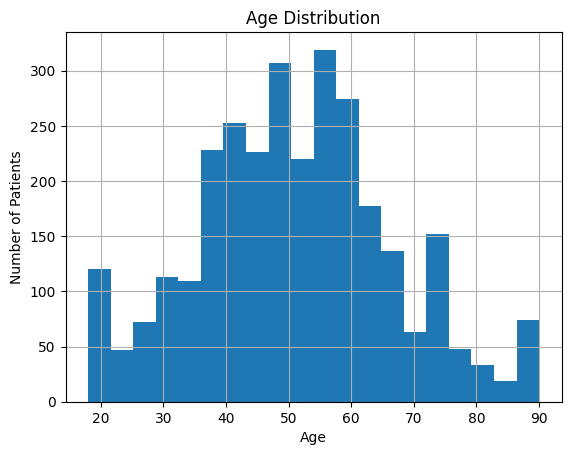

In [16]:
df['Age'].hist(bins=20)
plt.xlabel('Age')
plt.ylabel('Number of Patients')
plt.title('Age Distribution')
plt.show()

In [17]:
df['age_groups'] = pd.cut(df['Age'], bins= [18,30,40,50,60,70,80,90], labels= ['18-30','31-40','41-50','51-60','61-70','71-80','81-90'])

In [18]:
df['age_groups'].value_counts().sort_index()

,count
age_groups,
18-30,208
31-40,451
41-50,725
51-60,775
61-70,394
71-80,229
81-90,118


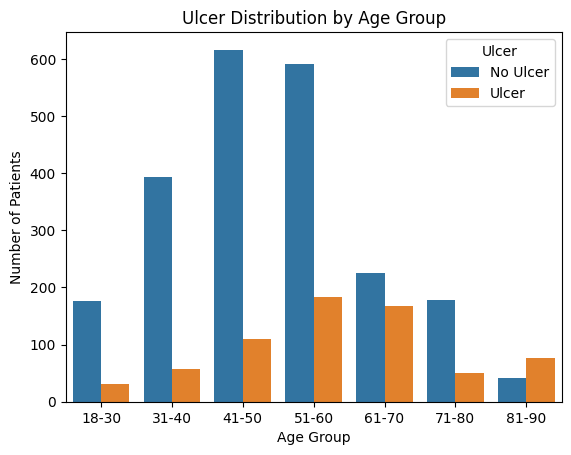

In [19]:
sns.countplot(data=df, x='age_groups', hue='Ulcer_Label')
plt.xlabel('Age Group')
plt.ylabel('Number of Patients')
plt.title('Ulcer Distribution by Age Group')
plt.legend(title='Ulcer', labels=['No Ulcer', 'Ulcer'])
plt.show()

### Analyze Risk Factors

Stress_Level
10    376
9     342
2     328
3     326
8     322
7     306
1     304
5     242
4     227
6     218
Name: count, dtype: int64


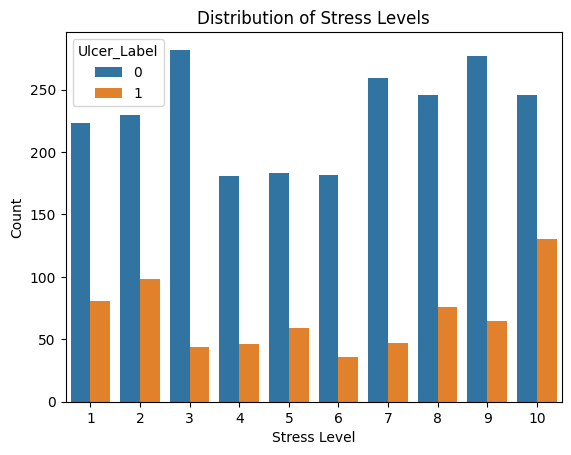

In [20]:
print(df['Stress_Level'].value_counts())
sns.countplot(data=df, x='Stress_Level', hue= 'Ulcer_Label')
plt.xlabel('Stress Level')
plt.ylabel('Count')
plt.title('Distribution of Stress Levels')
plt.show()

Gender
Male      1815
Female    1176
Name: count, dtype: int64


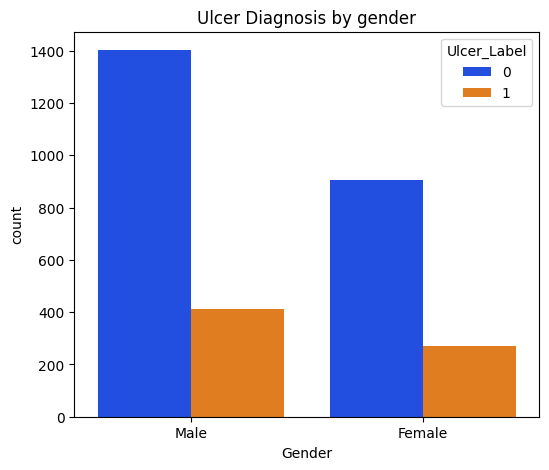

In [21]:
gender_count = df['Gender'].value_counts()
print(gender_count)
plt.figure(figsize=(6,5))
sns.countplot(data=df, x= 'Gender', hue= 'Ulcer_Label', palette= 'bright')
plt.title("Ulcer Diagnosis by gender")
plt.show()

Smoking
No     1958
Yes    1033
Name: count, dtype: int64


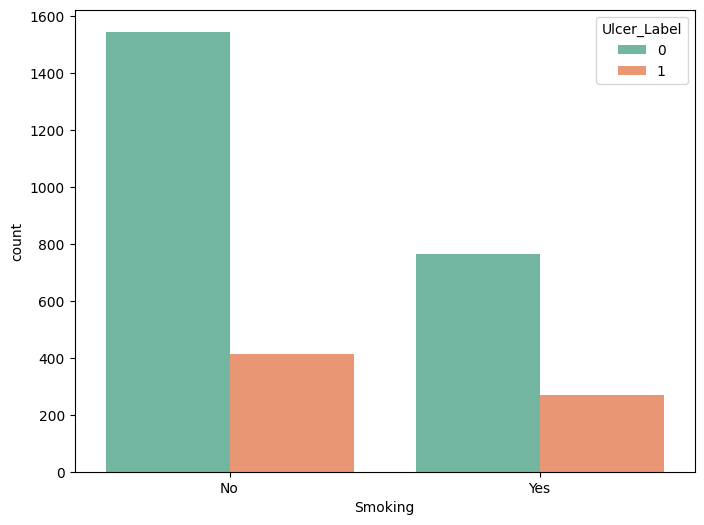

In [22]:
smoking_count = df['Smoking'].value_counts()
print(smoking_count)
plt.figure(figsize=(8,6))
sns.countplot(data= df, x= 'Smoking', hue= 'Ulcer_Label', palette = 'Set2')
plt.show()

Alcohol_Use
No     1663
Yes    1328
Name: count, dtype: int64


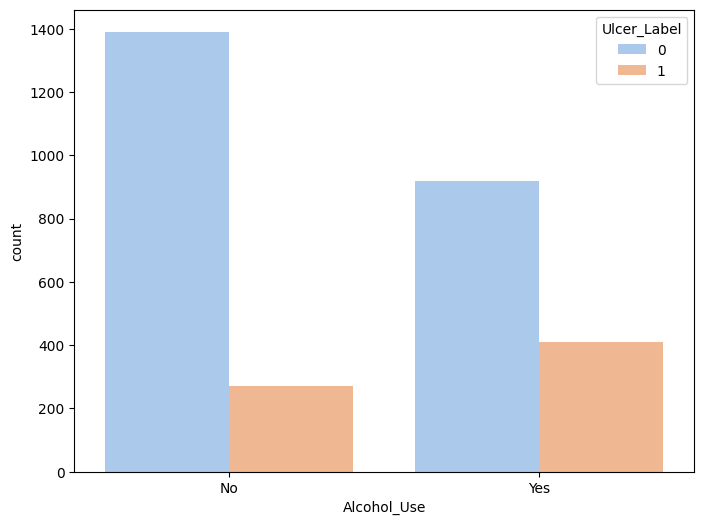

In [23]:
Alcohol_Use_count = df['Alcohol_Use'].value_counts()
print(Alcohol_Use_count)
plt.figure(figsize=(8,6))
sns.countplot(data= df, x= 'Alcohol_Use', hue= 'Ulcer_Label', palette = 'pastel')
plt.show()

NSAID_Use
No     1649
Yes    1342
Name: count, dtype: int64


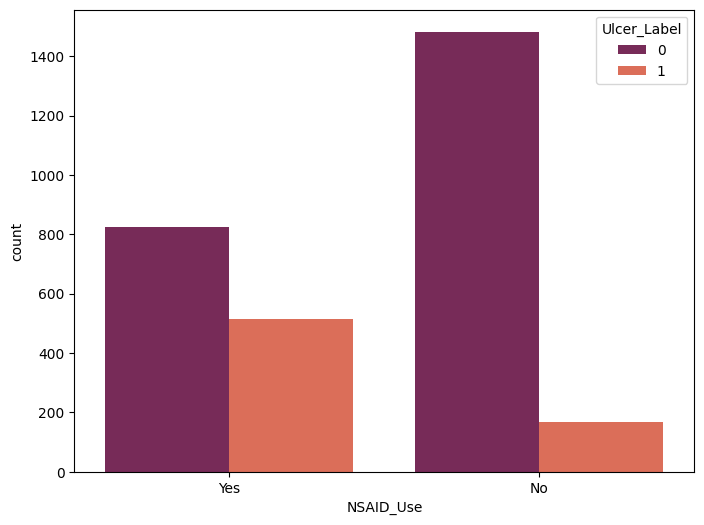

In [24]:
NSAID_Use_count = df['NSAID_Use'].value_counts()
print(NSAID_Use_count)
plt.figure(figsize=(8,6))
sns.countplot(data= df, x= 'NSAID_Use', hue= 'Ulcer_Label', palette = 'rocket')
plt.show()

In [25]:
for col in df.columns:
    if df[col].nunique() in [2,3]:
        print(col, df[col].unique())

Gender ['Male' 'Female']
Smoking ['No' 'Yes']
Alcohol_Use ['No' 'Yes']
NSAID_Use ['Yes' 'No']
Family_History ['No' 'Yes']
Abdominal_Pain ['No' 'Yes']
Nausea ['No' 'Yes']
Vomiting ['No' 'Yes']
Bloating ['No' 'Yes']
Loss_of_Appetite ['No' 'Yes']
Heartburn ['No' 'Yes']
Melena ['No' 'Yes']
Hematemesis ['Yes' 'No']
Ulcer_Label [0 1]


### Encode Categorical Features

In [26]:
df['Gender'] = df['Gender'].map({"Male": 1, "Female" : 0})
df['Smoking'] = df['Smoking'].map({"Yes": 1, "No": 0})
df['Alcohol_Use'] = df['Alcohol_Use'].map({"Yes": 1, "No": 0})
df['NSAID_Use']= df['NSAID_Use'].map({"Yes": 1, "No": 0})
df['Family_History'] = df['Family_History'].map({"Yes": 1, "No": 0})
df['Abdominal_Pain'] = df['Abdominal_Pain'].map({"Yes": 1, "No": 0})
df['Nausea'] = df['Nausea'].map({"Yes": 1, "No": 0})
df['Vomiting'] = df['Vomiting'].map({"Yes": 1, "No": 0})
df['Bloating'] = df['Bloating'].map({"Yes": 1, "No": 0})
df['Loss_of_Appetite'] = df['Loss_of_Appetite'].map({"Yes": 1, "No": 0})
df['Heartburn'] = df['Heartburn'].map({"Yes": 1, "No": 0})
df['Melena'] = df['Melena'].map({"Yes": 1, "No": 0})
df['Hematemesis'] = df['Hematemesis'].map({"Yes": 1, "No": 0})

In [27]:
for col in df.columns:
    print(col, df[col].unique())

Age [57 47 59 72 46 73 61 42 58 43 53 21 24 41 34 54 36 28 71 51 32 55 40 45
 77 49 62 31 20 30 52 48 27 39 65 23 44 63 37 64 33 70 18 50 56 78 86 67
 82 35 26 38 69 25 90 60 66 29 84 19 76 81 74 68 80 79 75 22 88 89 87 83]
Gender [1 0]
Height_cm [176.         147.         174.9        ... 179.3016056  173.94415628
 158.25231833]
Weight_kg [93.8        60.5        85.6        ... 79.17019781 72.47362836
 77.31703966]
Smoking [0 1]
Alcohol_Use [0 1]
NSAID_Use [1 0]
Stress_Level [ 6  4  2  3  1  8  5 10  9  7]
Family_History [0 1]
Abdominal_Pain [0 1]
Nausea [0 1]
Vomiting [0 1]
Bloating [0 1]
Loss_of_Appetite [0 1]
Heartburn [0 1]
Melena [0 1]
Hematemesis [1 0]
Ulcer_Risk_Score [0.3553     0.3752     0.5385     ... 0.177159   0.25990677 0.19434337]
Ulcer_Label [0 1]
age_groups ['51-60', '41-50', '71-80', '61-70', '18-30', '31-40', NaN, '81-90']
Categories (7, object): ['18-30' < '31-40' < '41-50' < '51-60' < '61-70' < '71-80' < '81-90']


In [28]:
df.columns

Index(['Age', 'Gender', 'Height_cm', 'Weight_kg', 'Smoking', 'Alcohol_Use',
       'NSAID_Use', 'Stress_Level', 'Family_History', 'Abdominal_Pain',
       'Nausea', 'Vomiting', 'Bloating', 'Loss_of_Appetite', 'Heartburn',
       'Melena', 'Hematemesis', 'Ulcer_Risk_Score', 'Ulcer_Label',
       'age_groups'],
      dtype='object')

In [29]:
df.drop('age_groups', axis=1, inplace=True)

### Feature Correlation & Distribution

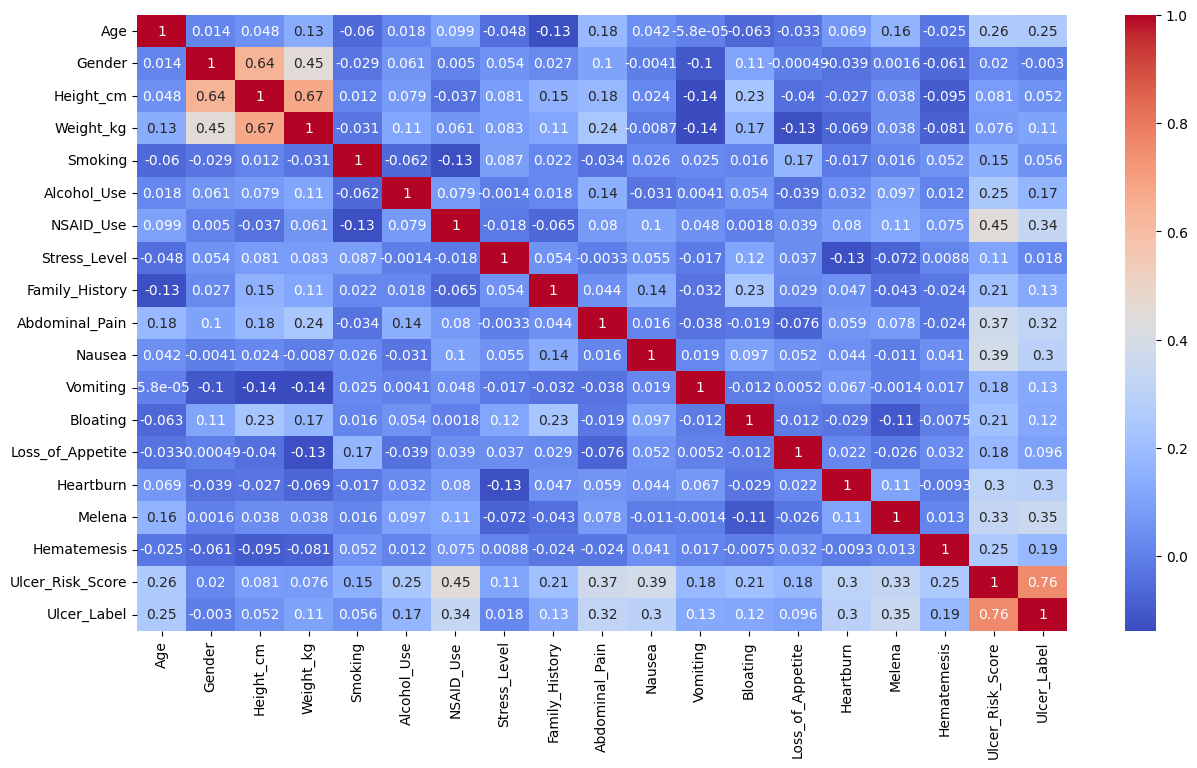

In [30]:
plt.figure(figsize=(15,8))
sns.heatmap(data=df.corr(), annot= True, cmap= 'coolwarm')
plt.show()

0.7091599680973875


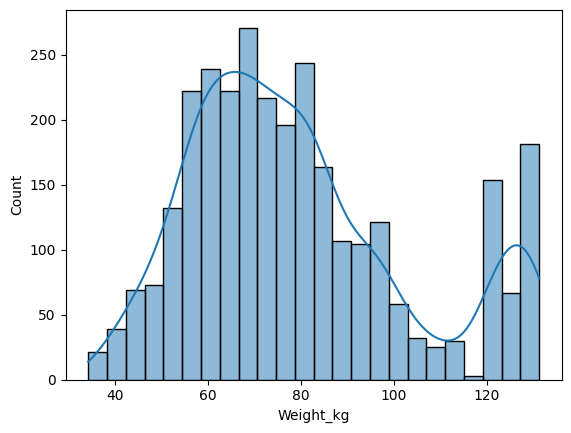

In [31]:
print(df['Weight_kg'].skew())
sns.histplot(df['Weight_kg'], kde=True)
plt.show()

0.3493850856286148


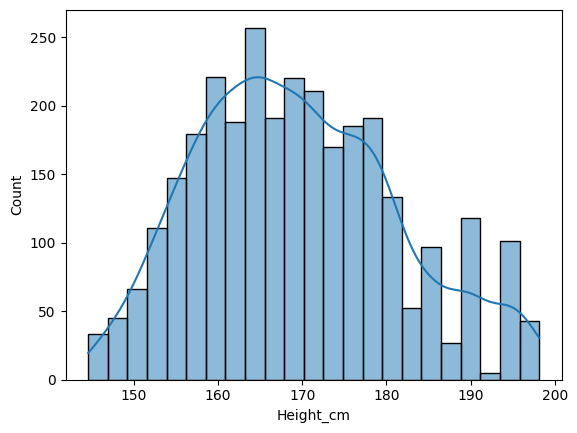

In [32]:
print(df['Height_cm'].skew())
sns.histplot(df['Height_cm'], kde=True)
plt.show()

### boxplots for outliers

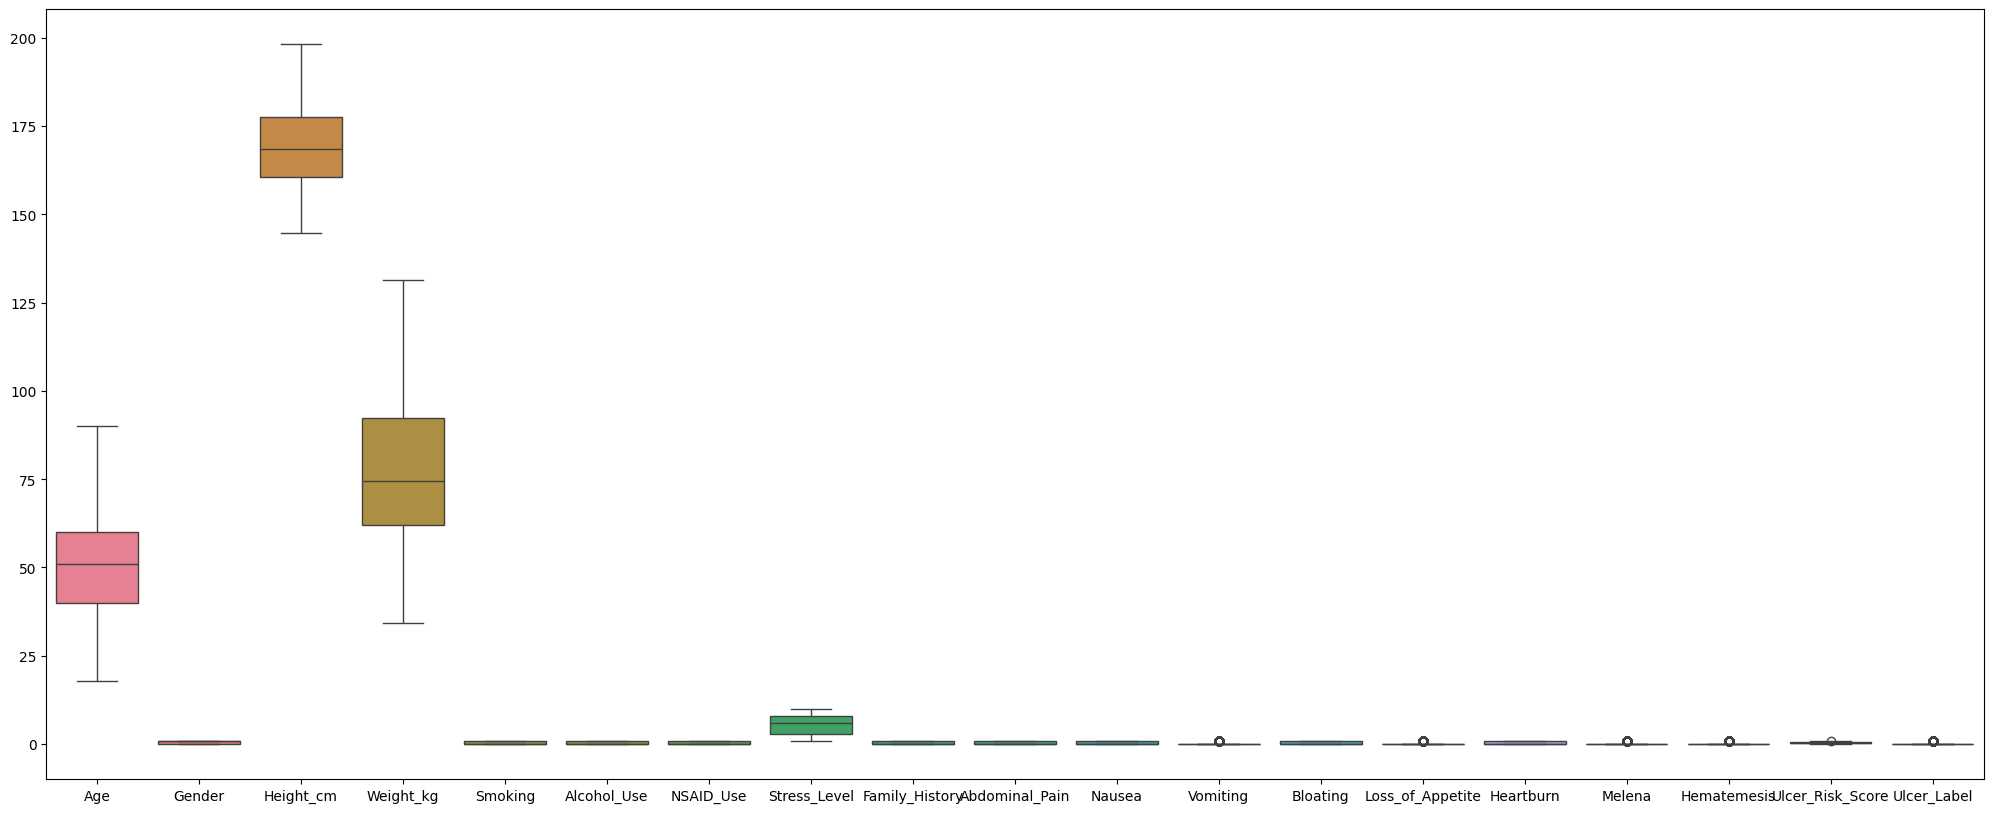

In [33]:
plt.figure(figsize=(25,10))
sns.boxplot(data= df)
plt.show()

In [34]:
df.columns

Index(['Age', 'Gender', 'Height_cm', 'Weight_kg', 'Smoking', 'Alcohol_Use',
       'NSAID_Use', 'Stress_Level', 'Family_History', 'Abdominal_Pain',
       'Nausea', 'Vomiting', 'Bloating', 'Loss_of_Appetite', 'Heartburn',
       'Melena', 'Hematemesis', 'Ulcer_Risk_Score', 'Ulcer_Label'],
      dtype='object')

### Prepare Data

In [35]:
x= df.drop(columns= ['Ulcer_Risk_Score', 'Ulcer_Label'])
y= df['Ulcer_Risk_Score']

### Split data: 80 - train /20 - test

In [36]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

### Scale numerical features using RobustScaler

In [37]:
Scaler = RobustScaler()
num_col = ['Age', 'Height_cm' ,'Weight_kg' , 'Stress_Level']

In [38]:
x_train[num_col] = Scaler.fit_transform(x_train[num_col])
x_test[num_col] = Scaler.transform(x_test[num_col])

In [39]:
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(2392, 17)
(599, 17)
(2392,)
(599,)


### Test 6 models with 5-fold CV on full dataset

In [40]:
Models = [LinearRegression(), RandomForestRegressor(), GradientBoostingRegressor(), KNeighborsRegressor(), XGBRegressor(), SVR(kernel= 'linear')]

In [41]:
for model in Models:
    print(f"------------------------{model}----------------------")
    cv_score = cross_val_score(model, x,y, cv=5)
    print(cv_score)
    print(cv_score.mean())

------------------------LinearRegression()----------------------
[0.77960952 0.78060471 0.8107549  0.82168111 0.74773203]
0.7880764549838257
------------------------RandomForestRegressor()----------------------
[0.79769637 0.80664949 0.90475866 0.97638425 0.95937931]
0.8889736185806708
------------------------GradientBoostingRegressor()----------------------
[0.78842311 0.78707469 0.88282848 0.88508034 0.80596054]
0.8298734334182368
------------------------KNeighborsRegressor()----------------------
[-0.02716882  0.04245433  0.57339078  0.53067703  0.28406833]
0.2806843332290115
------------------------XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_cons

### XGBoost Hyperparameter Tuning

In [42]:
xgb = XGBRegressor(objective='reg:squarederror', random_state=42)

In [43]:
param_grid = {'n_estimators': [300, 500, 800], 'learning_rate': [0.01, 0.05, 0.1], 'max_depth': [3, 5, 7],
    'subsample': [0.8, 1.0], 'colsample_bytree': [0.8, 1.0], 'gamma': [0, 0.1, 0.3]}

In [44]:
grid = GridSearchCV( estimator=xgb, param_grid=param_grid, cv=5, scoring='r2', n_jobs=-1, verbose=2)

### Fit model and retrieve best parameters

In [45]:
grid.fit(x_train, y_train)

Fitting 5 folds for each of 324 candidates, totalling 1620 fits


GridSearchCV(cv=5,
             estimator=XGBRegressor(base_score=None, booster=None,
                                    callbacks=None, colsample_bylevel=None,
                                    colsample_bynode=None,
                                    colsample_bytree=None, device=None,
                                    early_stopping_rounds=None,
                                    enable_categorical=False, eval_metric=None,
                                    feature_types=None, feature_weights=None,
                                    gamma=None, grow_policy=None,
                                    importance_type=None,
                                    interaction_constraints=None...
                                    max_depth=None, max_leaves=None,
                                    min_child_weight=None, missing=nan,
                                    monotone_constraints=None,
                                    multi_strategy=None, n_estimators=None,
                                    n_jobs=None, num_parallel_tree=None, ...),
             n_jobs=-1,
             param_grid={'colsample_bytree': [0.8, 1.0], 'gamma': [0, 0.1, 0.3],
                         'learning_rate': [0.01, 0.05, 0.1],
                         'max_depth': [3, 5, 7],
                         'n_estimators': [300, 500, 800],
                         'subsample': [0.8, 1.0]},
             scoring='r2', verbose=2)

In [46]:
print("Best Parameters:", grid.best_params_)
print("Best CV Score:", grid.best_score_)

best_model = grid.best_estimator_

Best Parameters: {'colsample_bytree': 0.8, 'gamma': 0, 'learning_rate': 0.05, 'max_depth': 7, 'n_estimators': 800, 'subsample': 0.8}
Best CV Score: 0.8791962875509188


### Evaluate - Predict on test set, calculate R² and RMSE

In [47]:
y_pred = best_model.predict(x_test)
print("Test R2:", r2_score(y_test, y_pred))
print("Test RMSE:", mean_squared_error(y_test, y_pred))

Test R2: 0.900595975353031
Test RMSE: 0.002914912393592899


### Save Model & Scaler

In [48]:
with open("best_model.pkl", "wb") as f:
  pickle.dump(best_model, f)
  print("model Successfully saved")

model Successfully saved


In [49]:
with open("scaler.pkl","wb") as s:
  pickle.dump(Scaler, s)
  print(" Successfully saved")

 Successfully saved
